# Structural Analysis

Reproduces the results for `APORIA` (**Section 4.1** and **Appendix C.2** of the paper) — the main structural analysis and associated tables:  
pairwise-distance distributions, Fisher separability, and the corresponding tables (Figures 2, 3 and 6; Tables 1, 10).  
Complements also the results for encoder ablation (Table 3), for the stemmed responses (Tables 8), and for CoQA-89K dataset (Table 12).

---

## Setup

In [1]:
import os
import pathlib

# allow execution from either the repo root or code/
ROOT = pathlib.Path.cwd()
if ROOT.name == "code":
    os.chdir(ROOT.parent)

os.environ["OPENBLAS_NUM_THREADS"] = "4"


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from matplotlib.patches import Rectangle, Patch

import aporia as ap


In [3]:
# ---------------------------------------------------------------
# Load dataset + model metadata from a TOML config.  Switching to a
# different dataset (e.g. CoQA) is a one-line change.
# ---------------------------------------------------------------
CONFIG_PATH = "config/socrates.toml"

cfg = ap.load_config(CONFIG_PATH)

# expose the names downstream plotting cells still use
model_names           = cfg.model_names
figures_dir           = cfg.cache.fig_dir
model_latextags       = cfg.model_latextags
best_reg_lambda       = cfg.experiment.best_lambda
maxResponsesPerPrompt = cfg.dataset.max_responses_per_prompt


In [4]:
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = ap.matplotlib_latex_preamble(cfg)


## Data

In [ ]:
df = ap.load_dataframe(cfg)


In [6]:
model_order, model_rank = ap.build_model_size_order(cfg)

false_premise = (
    {pid: fp for pid, fp in df[["prompt_id", "false_premise"]].value_counts().keys()}
    if "false_premise" in df.columns
    else None
)


## Experiment

In [7]:
results_df, geometry_store, null_store = ap.run_structural_analysis(
    df, cfg,
    use_cache=True,
    overwrite_cache=False,
)


Cache correctly loaded.


## Dataset statistics

### Distribution of the hallucinations

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Distribution of hallucination rates'}, xlabel='Hallucination rate (n_H / n_total)', ylabel='Number of (model, prompt) pairs'>)

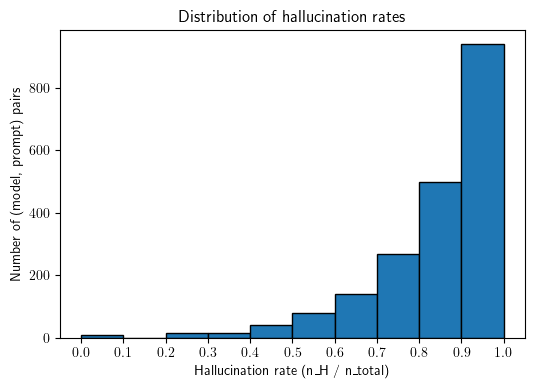

In [8]:
def plot_hallucination_ratio_histogram(results_df):
    frac_H = results_df["frac_H"].dropna()

    bins = np.linspace(0, 1, 11)  # 0, 0.2, ..., 1

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(frac_H, bins=bins, edgecolor="black")

    ax.set_xlabel("Hallucination rate (n_H / n_total)")
    ax.set_ylabel("Number of (model, prompt) pairs")
    ax.set_xticks(bins)

    ax.set_title("Distribution of hallucination rates")

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

plot_hallucination_ratio_histogram(results_df)

(<Figure size 2100x700 with 2 Axes>,
 <Axes: title={'center': 'Hallucination rates per model and prompt'}, xlabel='Prompts (sorted by hallucination rate)'>)

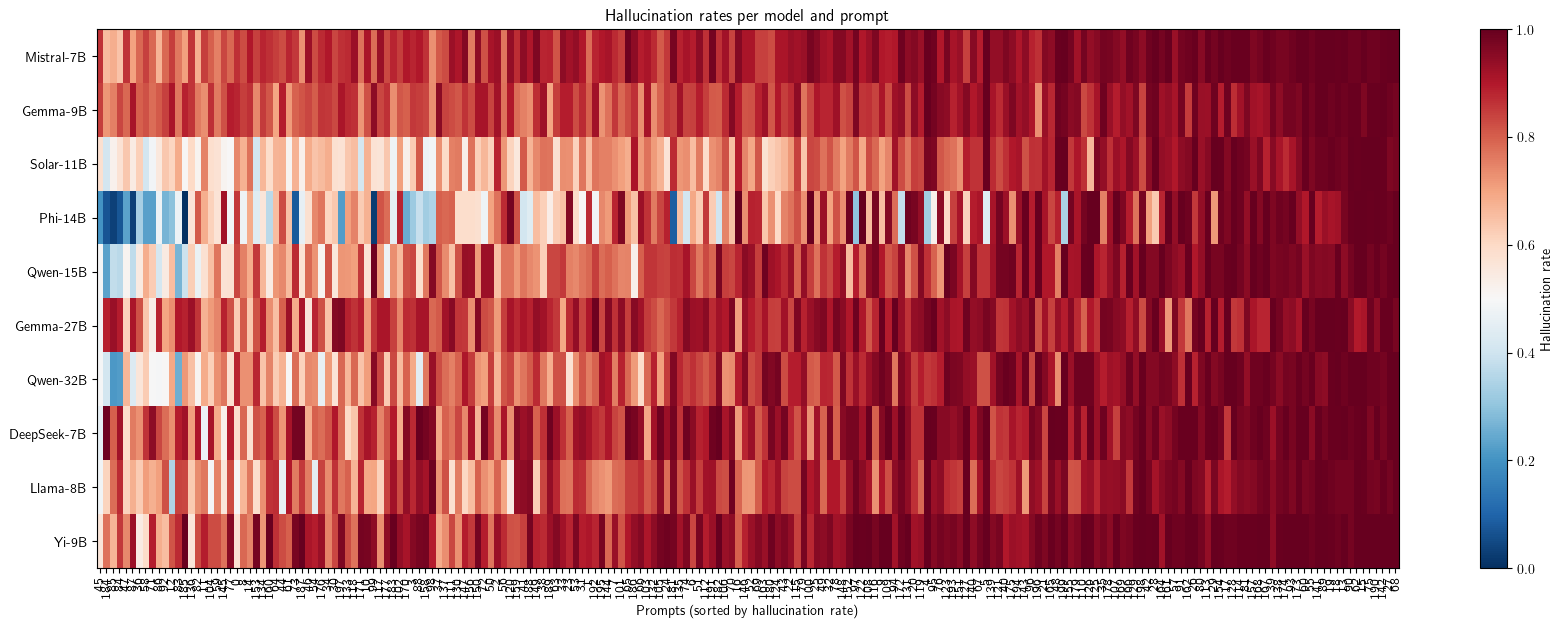

In [9]:
def plot_hallucination_rate_heatmap(results_df, model_names):
    pivot = results_df.pivot(
        index="model_id",
        columns="prompt_id",
        values="frac_H"
    )

    # sort prompts by mean hallucination rate
    prompt_order = pivot.mean(axis=0).sort_values().index
    pivot = pivot[prompt_order]

    fig, ax = plt.subplots(figsize=(21, 7))

    im = ax.imshow(
        pivot.values,
        aspect="auto",
        cmap="RdBu_r",
        vmin=0,
        vmax=1
    )

    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([model_names[m] for m in pivot.index])

    ax.set_xticks([x for x, _ in enumerate(prompt_order)])
    ax.set_xticklabels([x for x in prompt_order], rotation=90, ha='center')
    ax.set_xlabel("Prompts (sorted by hallucination rate)")

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label("Hallucination rate")

    ax.set_title("Hallucination rates per model and prompt")

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

plot_hallucination_rate_heatmap(results_df, model_names)

### Number of responses per prompt and their validity

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Response count per (model, prompt)'}, xlabel='Number of responses per (model, prompt)', ylabel='Count'>)

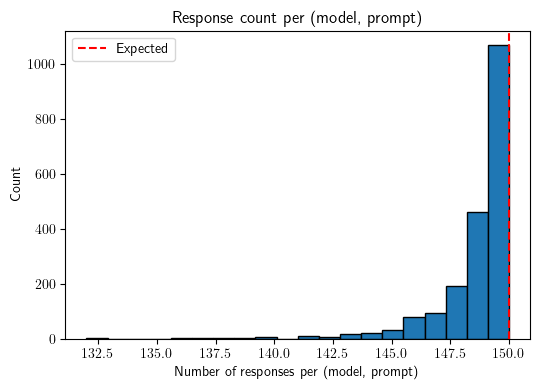

In [10]:
def plot_response_count_histogram(results_df, expected=500):
    n_total = results_df["n_total"]

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.hist(n_total, bins=20, edgecolor="black")

    ax.axvline(expected, linestyle="--", color="red", label="Expected")

    ax.set_xlabel("Number of responses per (model, prompt)")
    ax.set_ylabel("Count")
    ax.legend()

    ax.set_title("Response count per (model, prompt)")

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

plot_response_count_histogram(results_df, expected=maxResponsesPerPrompt)

(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'Coverage of valid configurations'}, ylabel='Number of (model, prompt) pairs'>)

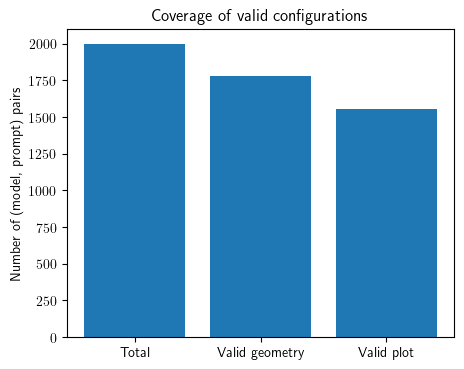

In [11]:
def plot_validity_coverage(results_df):
    counts = {
        "Total": len(results_df),
        "Valid geometry": results_df["valid_geom"].sum(),
        "Valid plot": results_df["valid_plot"].sum(),
    }

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.bar(counts.keys(), counts.values())

    ax.set_ylabel("Number of (model, prompt) pairs")
    ax.set_title("Coverage of valid configurations")

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

plot_validity_coverage(results_df)

(<Figure size 600x400 with 1 Axes>,
 <Axes: title={'center': 'Validity fraction per model'}, xlabel='model_id', ylabel='Fraction'>)

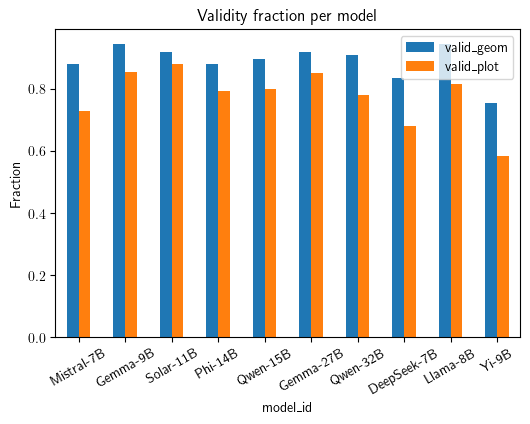

In [12]:
def plot_validity_by_model(results_df, model_names):
    grouped = results_df.groupby("model_id")[["valid_geom", "valid_plot"]].mean()

    fig, ax = plt.subplots(figsize=(6, 4))
    grouped.plot.bar(ax=ax)

    ax.set_ylabel("Fraction")
    ax.set_xticklabels([model_names[m] for m in grouped.index], rotation=30)
    ax.set_title("Validity fraction per model")

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

plot_validity_by_model(results_df, model_names)

## H_0 experiment -- Figs. 3, 6

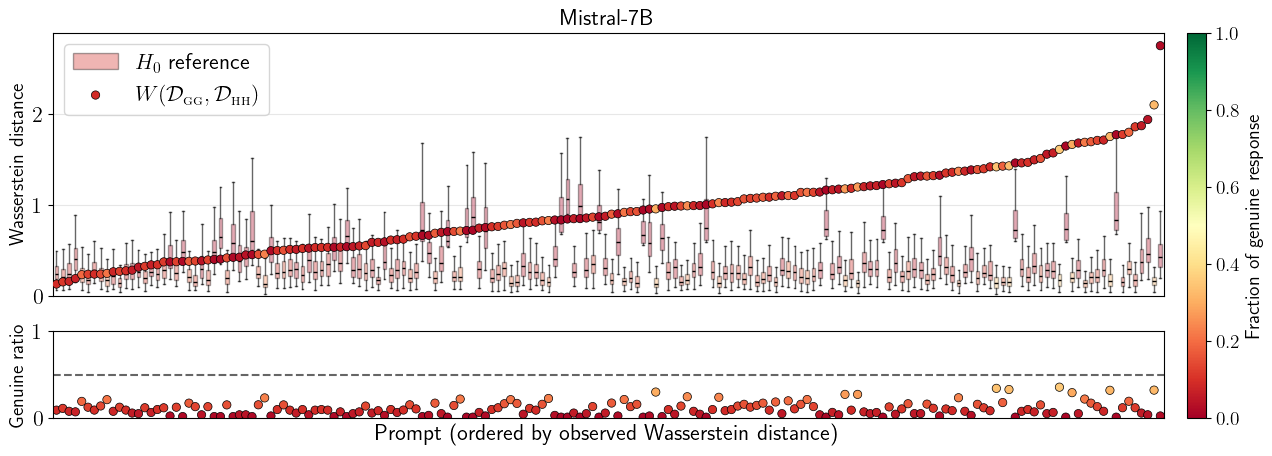

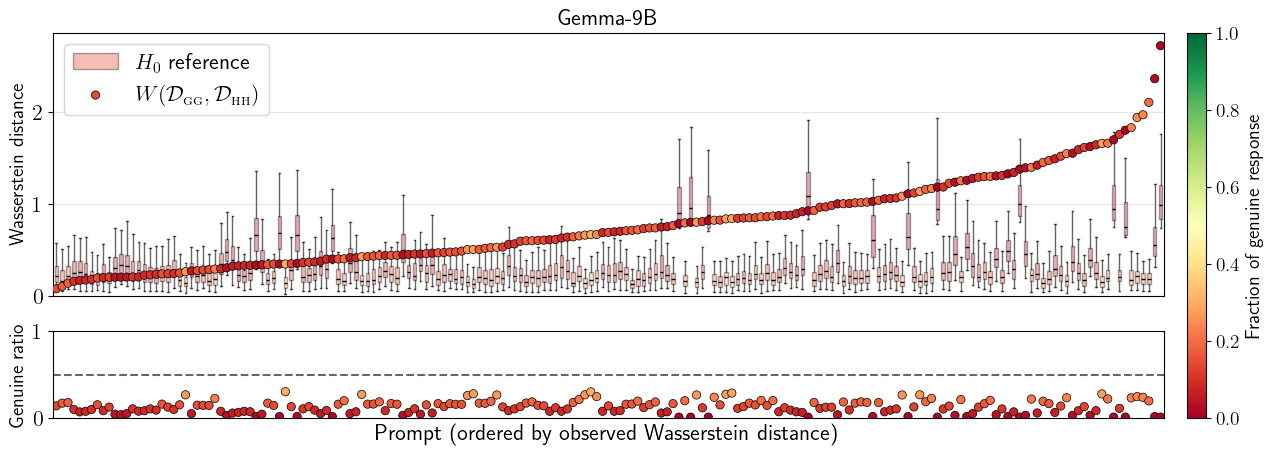

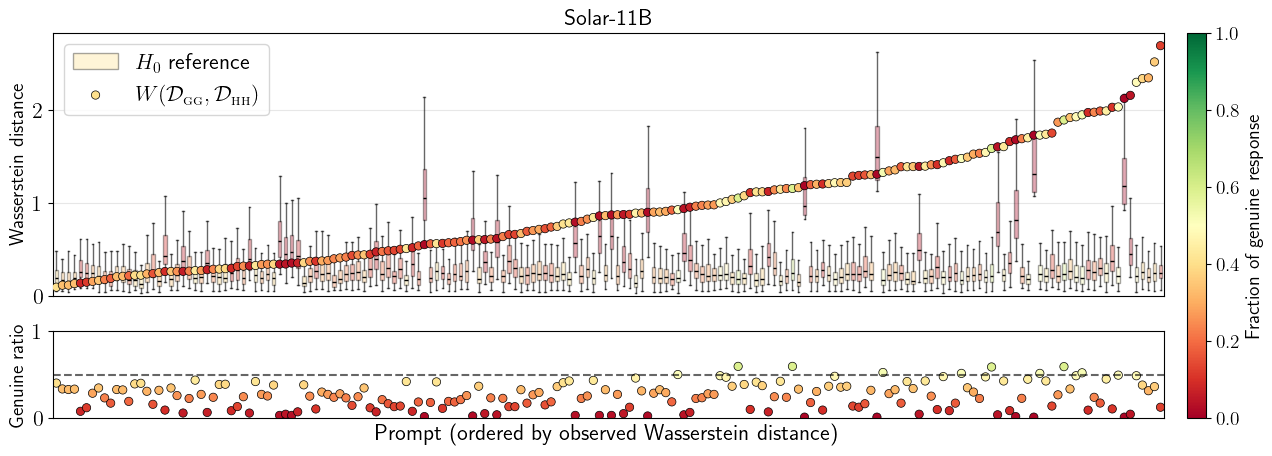

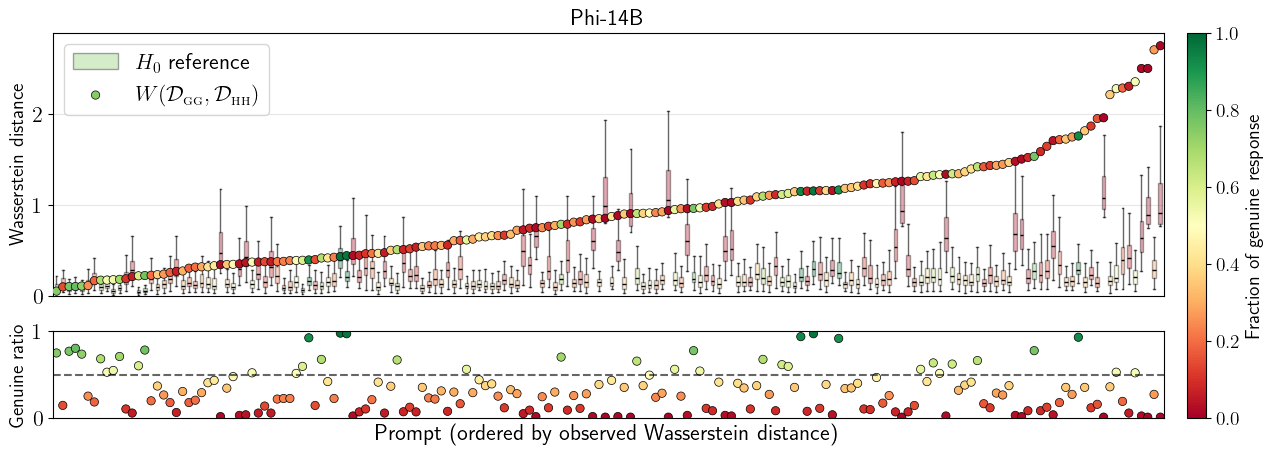

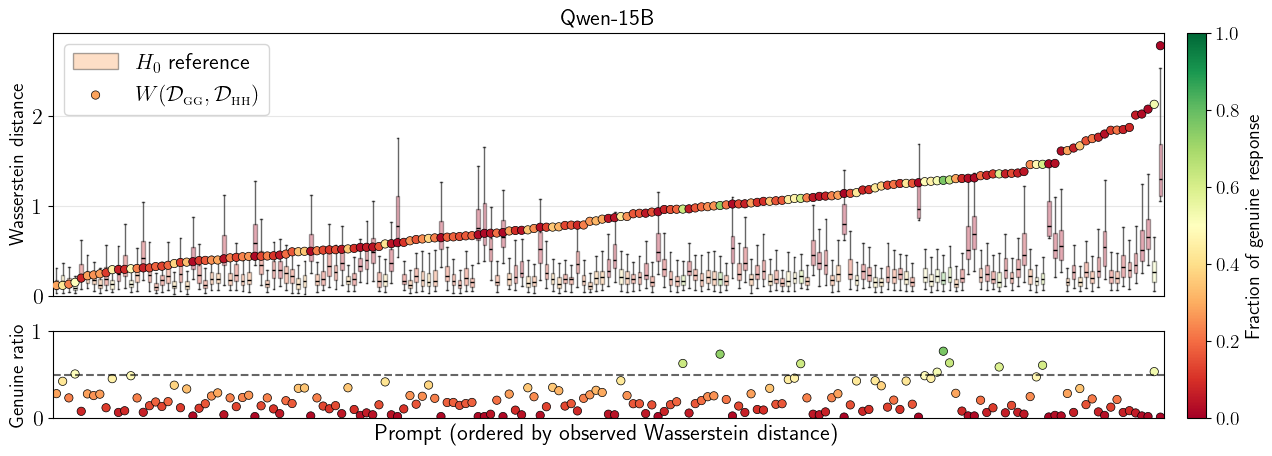

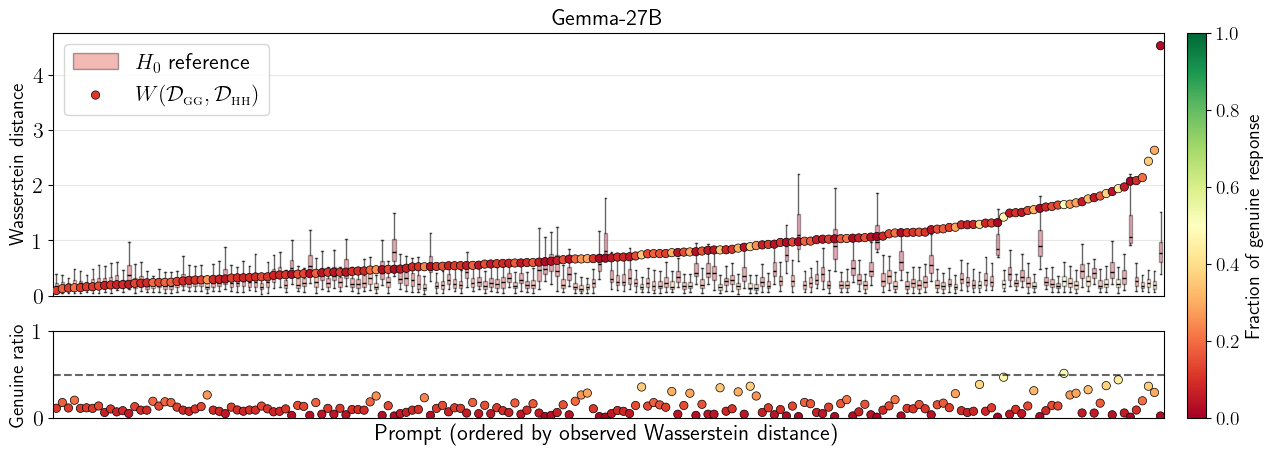

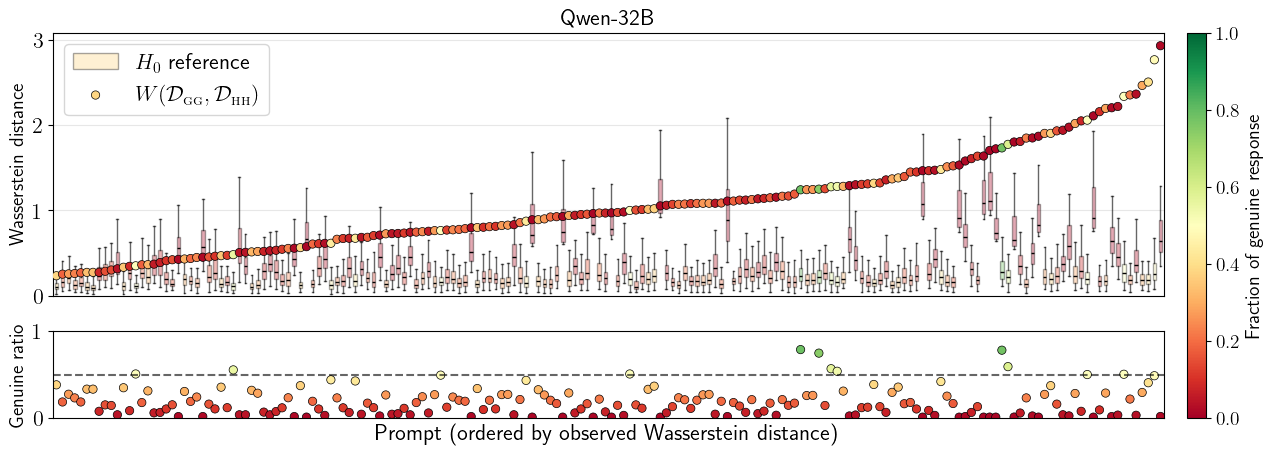

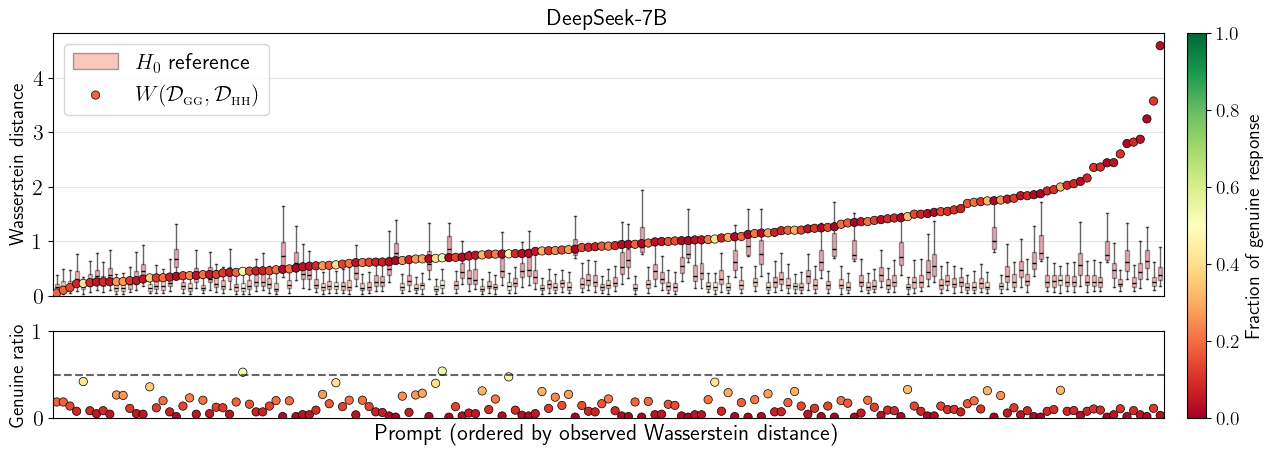

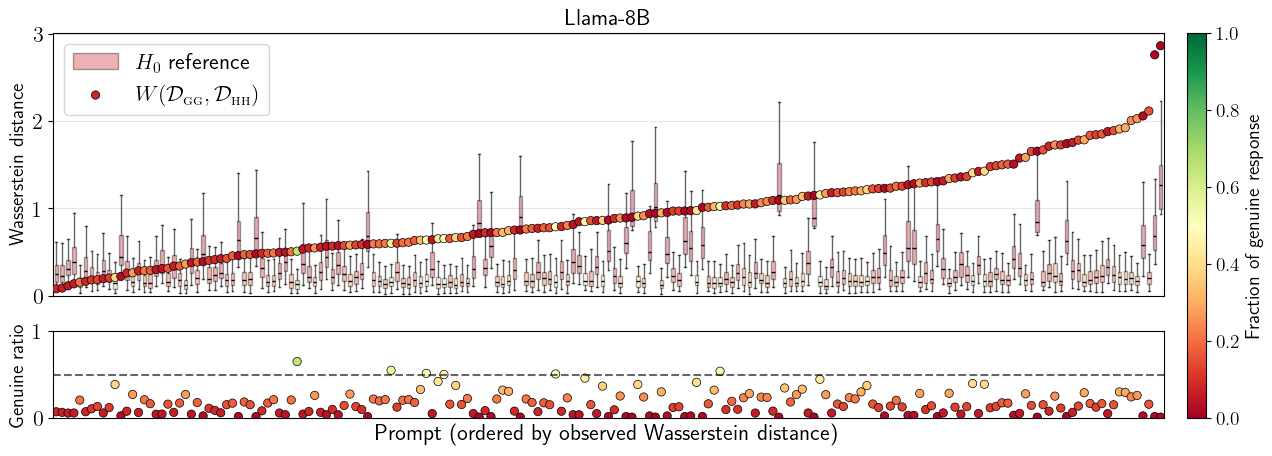

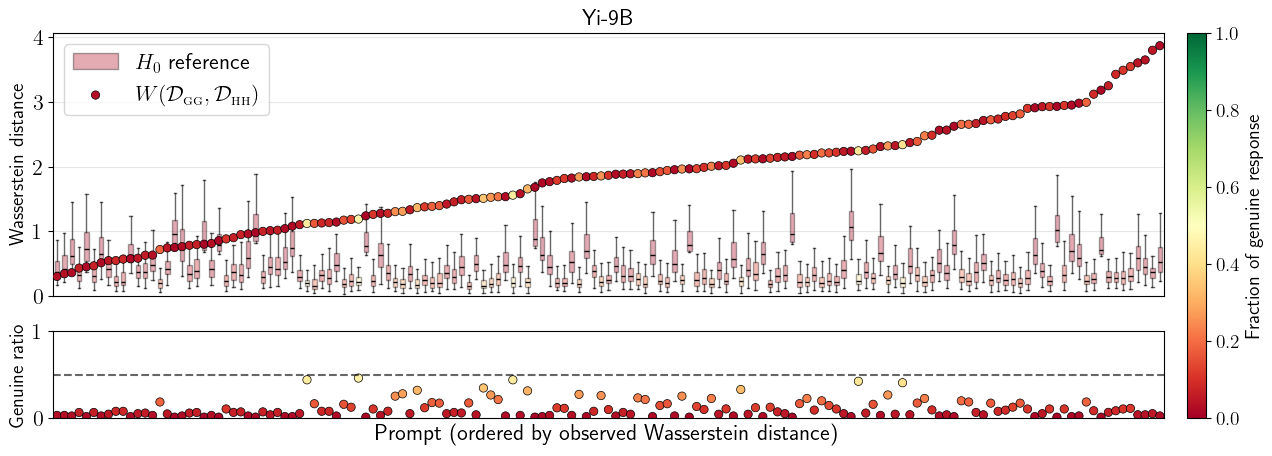

In [13]:
def plot_wasserstein_ordered_with_null(
    df_model,
    null_store,
    model_id,
    ax=None,
    axc=None,
    title=None,
    show_fliers=False,
    cmap_name="berlin",
    requireValidPlot=False,
    false_premise=None
):
    """
    Plot observed Wasserstein distances ordered by magnitude,
    with corresponding null distributions as boxplots,
    colour-coded by fraction of genuine responses.
    """
    # ---- filter prompts with available null model ----
    rows = []
    for _, r in df_model.iterrows():
        if requireValidPlot and not r["valid_plot"]:
            continue
        key = (model_id, r["prompt_id"])
        if key in null_store and len(null_store[key]) > 0:
            rows.append(r)

    if len(rows) == 0:
        raise ValueError("No prompts with available null distributions")

    df = (
        df_model
        .loc[[r.name for r in rows]]
        .sort_values("W_GG_HH")
        .reset_index(drop=True)
    )

    # ---- data ----
    W_obs = df["W_GG_HH"].values
    prompt_ids = df["prompt_id"].values
    genuine = df["frac_G"].values
    x = np.arange(len(W_obs))

    W_null_list = [
        null_store[(model_id, p)]
        for p in prompt_ids
    ]

    # ---- colour mapping ----
    cmap = plt.get_cmap(cmap_name)
    norm = mcolors.TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)
    colors = cmap(norm(genuine))

    # ---- figure / axes ----
    if ax is None:
        fig, (ax, axc) = plt.subplots(
            2, 1,
            sharex=True,
            height_ratios=[3, 1],
            figsize=(15, 5),
            
        )
    else:
        fig = ax.figure

    # ---- null boxplots ----
    bp = ax.boxplot(
        W_null_list,
        positions=x,
        widths=0.6,
        showfliers=show_fliers,
        patch_artist=True,
        medianprops=dict(color="black"),
        whiskerprops=dict(alpha=0.6),
        capprops=dict(alpha=0.6),
        label="$H_0$ reference"
    )

    # colour each box
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.35)

    # ---- observed scatter ----
    if false_premise is None:
        sub = [True for pid in prompt_ids]
    else:
        sub = [(not false_premise[pid]) for pid in prompt_ids]

    ax.scatter(
        x[sub],
        W_obs[sub],
        c=colors[sub],
        edgecolor="black",
        marker='o',
        linewidth=0.5,
        zorder=3,
        label="$W(\\mathcal{D}_{\\textsc{gg}}, \\mathcal{D}_{\\textsc{hh}})$"
    )
    if False in sub:
        ax.scatter(
            x[[not s for s in sub]],
            W_obs[[not s for s in sub]],
            c=colors[[not s for s in sub]],
            edgecolor="black",
            marker='*',
            linewidth=0.5,
            zorder=3,
            label="$W(\\mathcal{D}_{\\textsc{gg}}, \\mathcal{D}_{\\textsc{hh}})$ (False premise)"
        )

    # ---- styling ----
    ax.set_ylabel("Wasserstein distance", size=14)
    ax.set_xlim(-0.5, len(x) - 0.5)
    ax.set_ylim(bottom=0)

    if title is None:
        title = f"{model_names[model_id]}"
    ax.set_title(title, size=16)

    ax.legend(loc="upper left", fontsize=16)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_xticks([])

    # ---- fraction panel ----
    if axc is not None:
        axc.scatter(
            x[sub],
            genuine[sub],
            c=colors[sub],
            edgecolor="black",
            linewidth=0.5
        )
        if False in sub:
            axc.scatter(
                x[[not s for s in sub]],
                genuine[[not s for s in sub]],
                c=colors[[not s for s in sub]],
                marker='*',
                edgecolor="black",
                linewidth=0.5
            )
        axc.axhline(0.5, color="black", linestyle="--", alpha=0.6)
        axc.set_ylim(0, 1)
        axc.set_ylabel("Genuine ratio", size=14)
        axc.set_xlabel("Prompt (ordered by observed Wasserstein distance)", size=16)

    # ---- colourbar ----
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = fig.colorbar(
        sm,
        ax=[ax, axc] if axc is not None else ax,
        fraction=0.025,
        pad=0.02
    )
    cbar.set_label("Fraction of genuine response", size=14)
    cbar.ax.tick_params(labelsize=14)
    ax.tick_params(labelsize=16)
    axc.tick_params(labelsize=16)

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

for tmp_model_id in range(len(model_names)):
    df_model = results_df[
        (results_df["model_id"] == tmp_model_id) &
        (results_df["valid_geom"])
    ]

    fig, ax = plot_wasserstein_ordered_with_null(
        df_model=df_model,
        null_store=null_store,
        model_id=tmp_model_id,
        show_fliers=False,
        false_premise=false_premise,
        cmap_name="RdYlGn"
    )

    # if model_names[tmp_model_id] == "Phi-14B":
    #     fig.savefig(f"{figures_dir}/S_WassVsNull_Phi.pdf", bbox_inches='tight')
    fig.savefig(f"{figures_dir}/S_WassVsNull_{model_names[tmp_model_id]}.pdf", bbox_inches='tight')

## Distribution of D_GG and D_HH values across prompts.

### Sorted by balancedeness (frac_G closest to 0.0, 0.5, 1.0) w.r.t. Fisher space

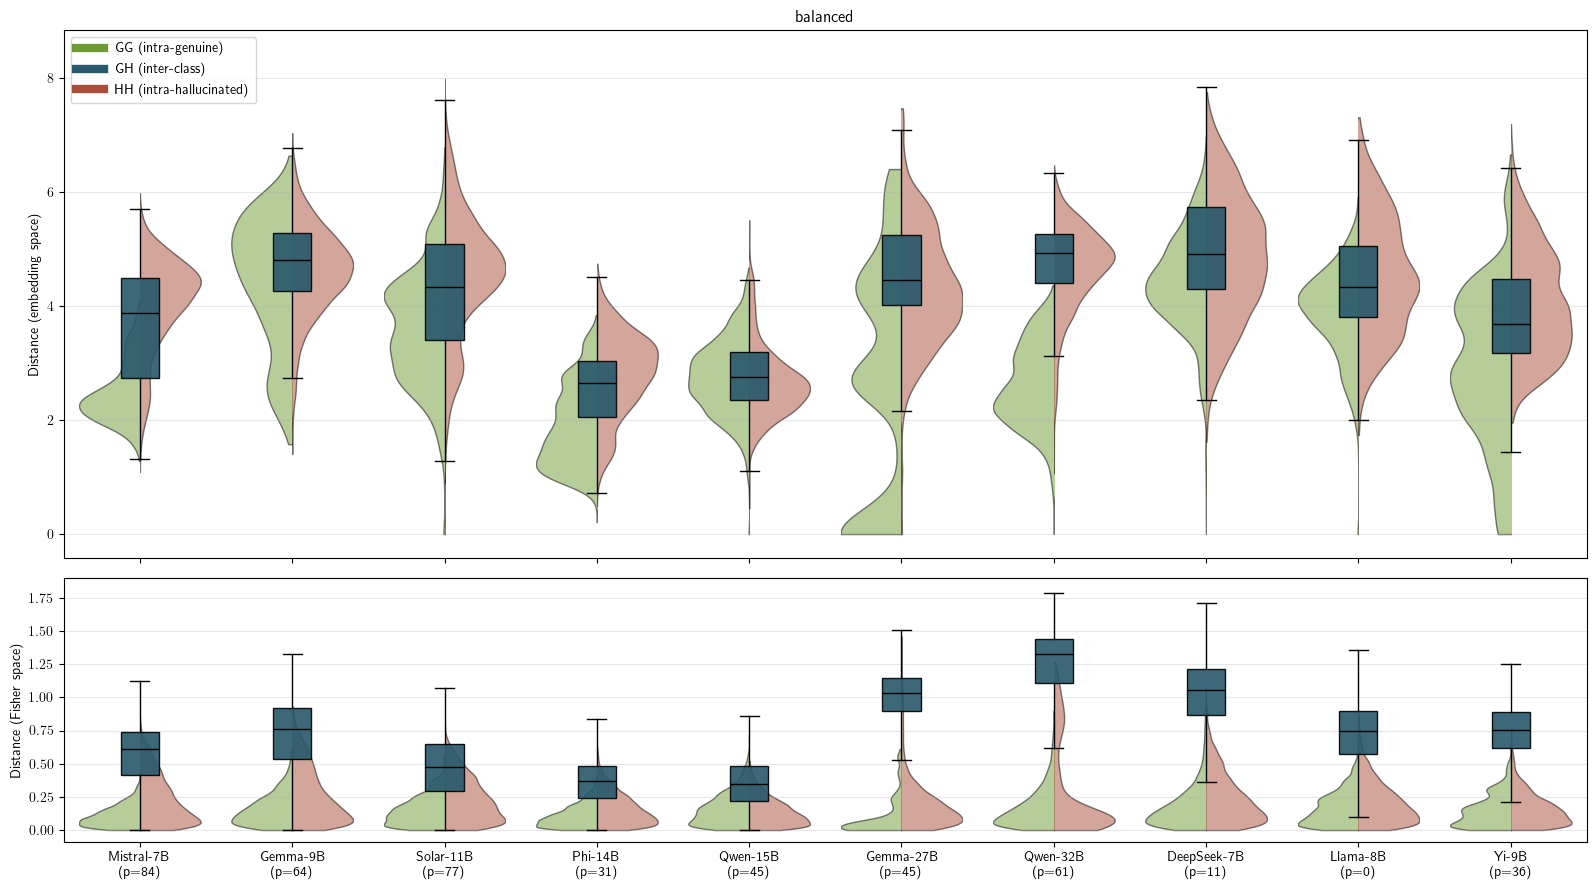

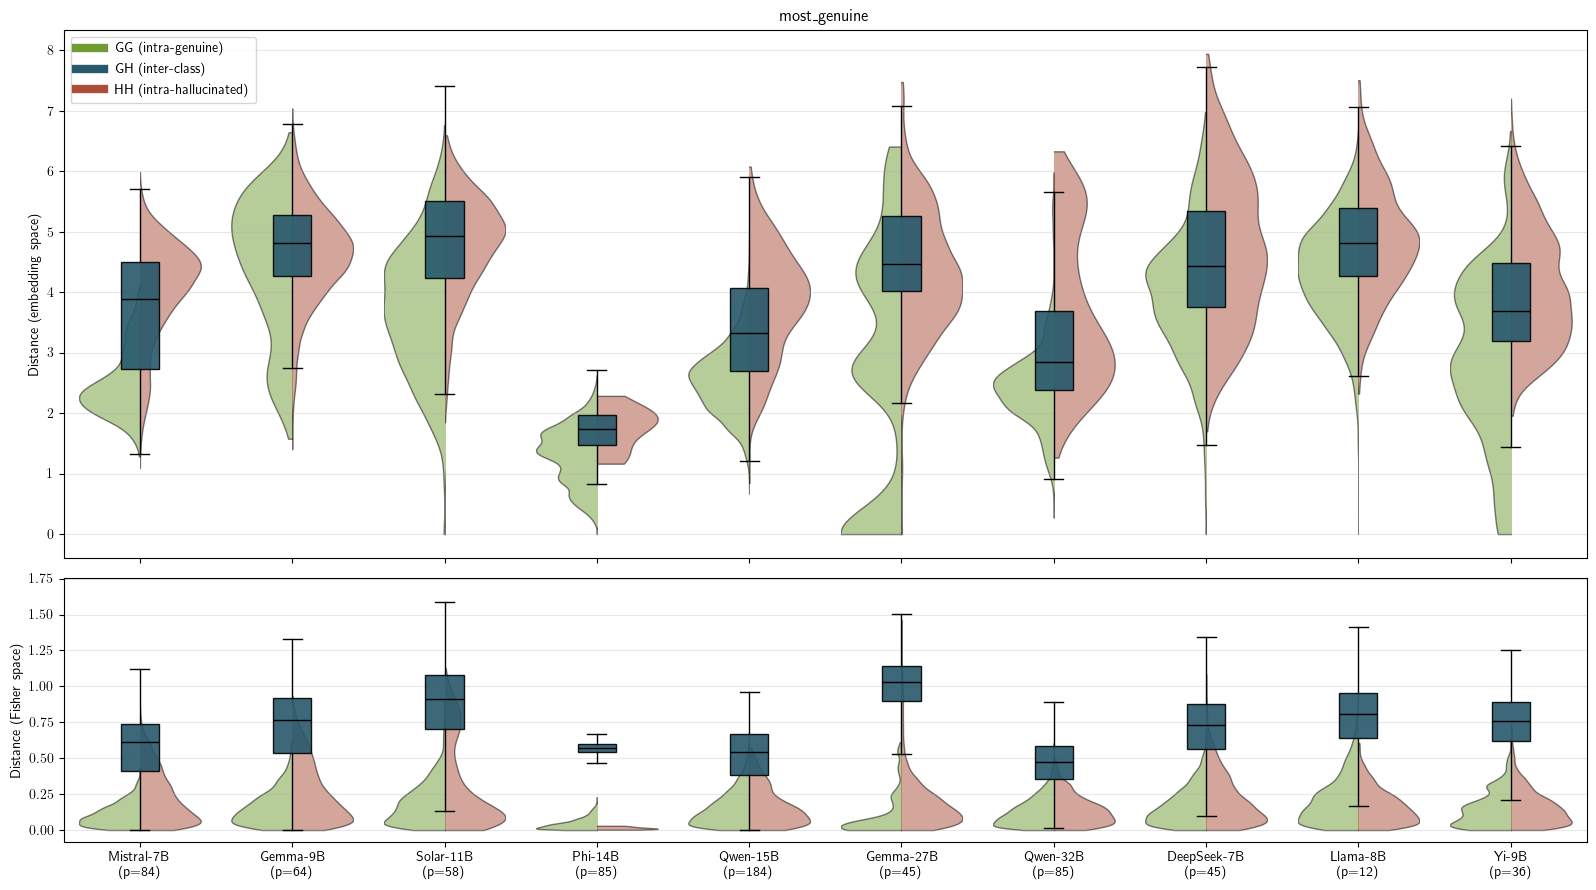

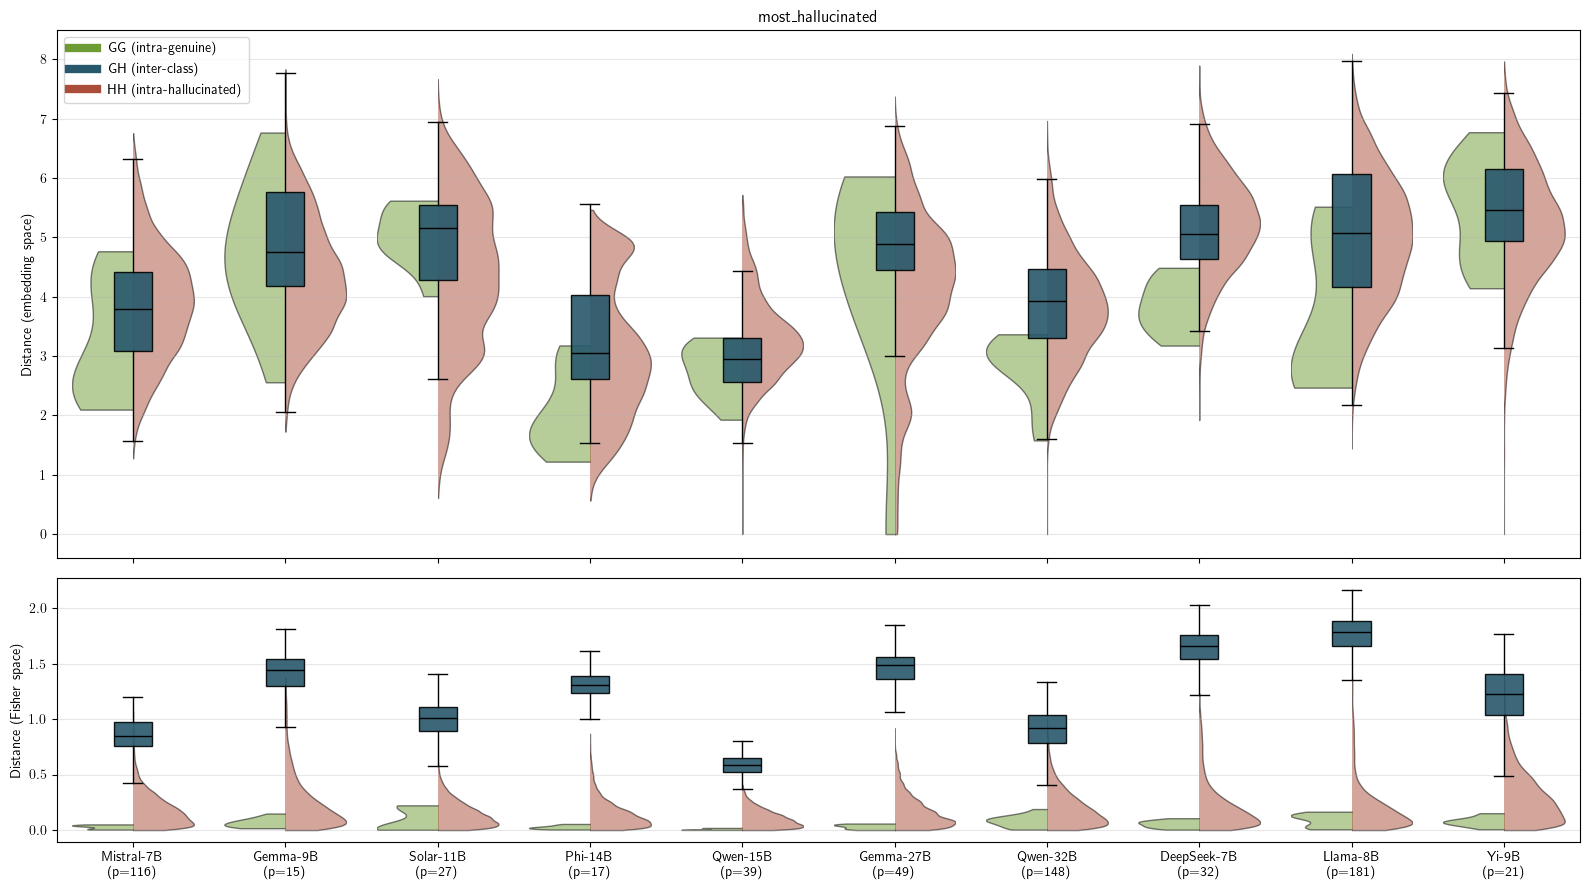

In [14]:
def plot_violin_box_distance_panels_fisher(
    geometry_store,
    selected_keys,
    model_names,
    figsize=(14, 8),
    violin_width=0.8,
    box_width=0.25,
    alpha_violin=0.5,
    title=None
):
    """
    Two-panel plot (embedding / Fisher space) with:
      - left half violin: intra-genuine (GG)
      - boxplot: inter-class (GH)
      - right half violin: intra-hallucinated (HH)
    """

    KEYMAP = {
        "emb": ("D_GG", "D_HH", "D_GH"),
        "fisher": ("D_GG_z", "D_HH_z", "D_GH_z")
    }

    COLORS = {
        "GG": "#6E9B34",  # green
        "HH": "#AA4D39",  # red
        "GH": "#27586B",  # blue
    }

    n = len(selected_keys)
    x = np.arange(n)

    fig, axes = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )

    def _plot_panel(ax, space_key, ylabel):
        key_GG, key_HH, key_GH = KEYMAP[space_key]

        # ---- global y-limits
        all_vals = []
        for k in selected_keys:
            d = geometry_store[k]
            all_vals.extend(d[key_GG])
            all_vals.extend(d[key_HH])
            all_vals.extend(d[key_GH])

        all_vals = np.asarray(all_vals)
        all_vals = all_vals[np.isfinite(all_vals)]

        ymin, ymax = all_vals.min(), all_vals.max()
        pad = 0.05 * (ymax - ymin)
        ax.set_ylim(ymin - pad, ymax + pad)

        y0, y1 = ax.get_ylim()
        height = y1 - y0

        for i, (m, p) in enumerate(selected_keys):
            d = geometry_store[(m, p)]

            # ---- GG: left half violin
            vp = ax.violinplot(
                d[key_GG],
                positions=[x[i]],
                widths=violin_width,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )
            for pc in vp["bodies"]:
                pc.set_facecolor(COLORS["GG"])
                pc.set_edgecolor("black")
                pc.set_linewidth(1.0)
                pc.set_alpha(alpha_violin)
                pc.set_clip_path(
                    Rectangle(
                        (x[i] - violin_width / 2, y0),
                        violin_width / 2,
                        height,
                        transform=ax.transData
                    )
                )

            # ---- HH: right half violin
            vp = ax.violinplot(
                d[key_HH],
                positions=[x[i]],
                widths=violin_width,
                showmeans=False,
                showmedians=False,
                showextrema=False
            )
            for pc in vp["bodies"]:
                pc.set_facecolor(COLORS["HH"])
                pc.set_edgecolor("black")
                pc.set_linewidth(1.0)
                pc.set_alpha(alpha_violin)
                pc.set_clip_path(
                    Rectangle(
                        (x[i], y0),
                        violin_width / 2,
                        height,
                        transform=ax.transData
                    )
                )

            # ---- GH: boxplot
            bp = ax.boxplot(
                d[key_GH],
                positions=[x[i]],
                widths=box_width,
                patch_artist=True,
                showfliers=False
            )
            for box in bp["boxes"]:
                box.set_facecolor(COLORS["GH"])
                box.set_edgecolor("black")
                box.set_alpha(0.9)

            for elem in ["whiskers", "caps", "medians"]:
                for artist in bp[elem]:
                    artist.set_color("black")

        ax.set_ylabel(ylabel)
        ax.grid(True, axis="y", alpha=0.3)

    # ---- plot panels
    _plot_panel(axes[0], "emb", "Distance (embedding space)")
    _plot_panel(axes[1], "fisher", "Distance (Fisher space)")

    # ---- x-axis labels
    labels = [
        f"{model_names[m]}\n(p={p})"
        for m, p in selected_keys
    ]
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels)#, rotation=30, ha="right")

    if title is None:
        title = "Distance distributions across models and prompts"
    axes[0].set_title(title)

    # ---- legend
    handles = [
        plt.Line2D([0], [0], color=COLORS["GG"], lw=6, label="GG (intra-genuine)"),
        plt.Line2D([0], [0], color=COLORS["GH"], lw=6, label="GH (inter-class)"),
        plt.Line2D([0], [0], color=COLORS["HH"], lw=6, label="HH (intra-hallucinated)"),
    ]
    axes[0].legend(handles=handles, loc="upper left")

    fig.tight_layout()
    return fig, axes

# ===== ===== ===== ===== ===== ===== ===== =====

sks = [ap.select_representative_prompts(results_df, model_id=mid) for mid in range(len(model_names))]

for kk in sks[0].keys():
    selk = [(dd[kk]['model_id'], dd[kk]['prompt_id']) for dd in sks]

    fig, axes = plot_violin_box_distance_panels_fisher(
        geometry_store=geometry_store,
        selected_keys=selk,
        model_names=model_names,
        figsize=(16, 9),
        title=kk
    )

### Single model example: Mistral-7B

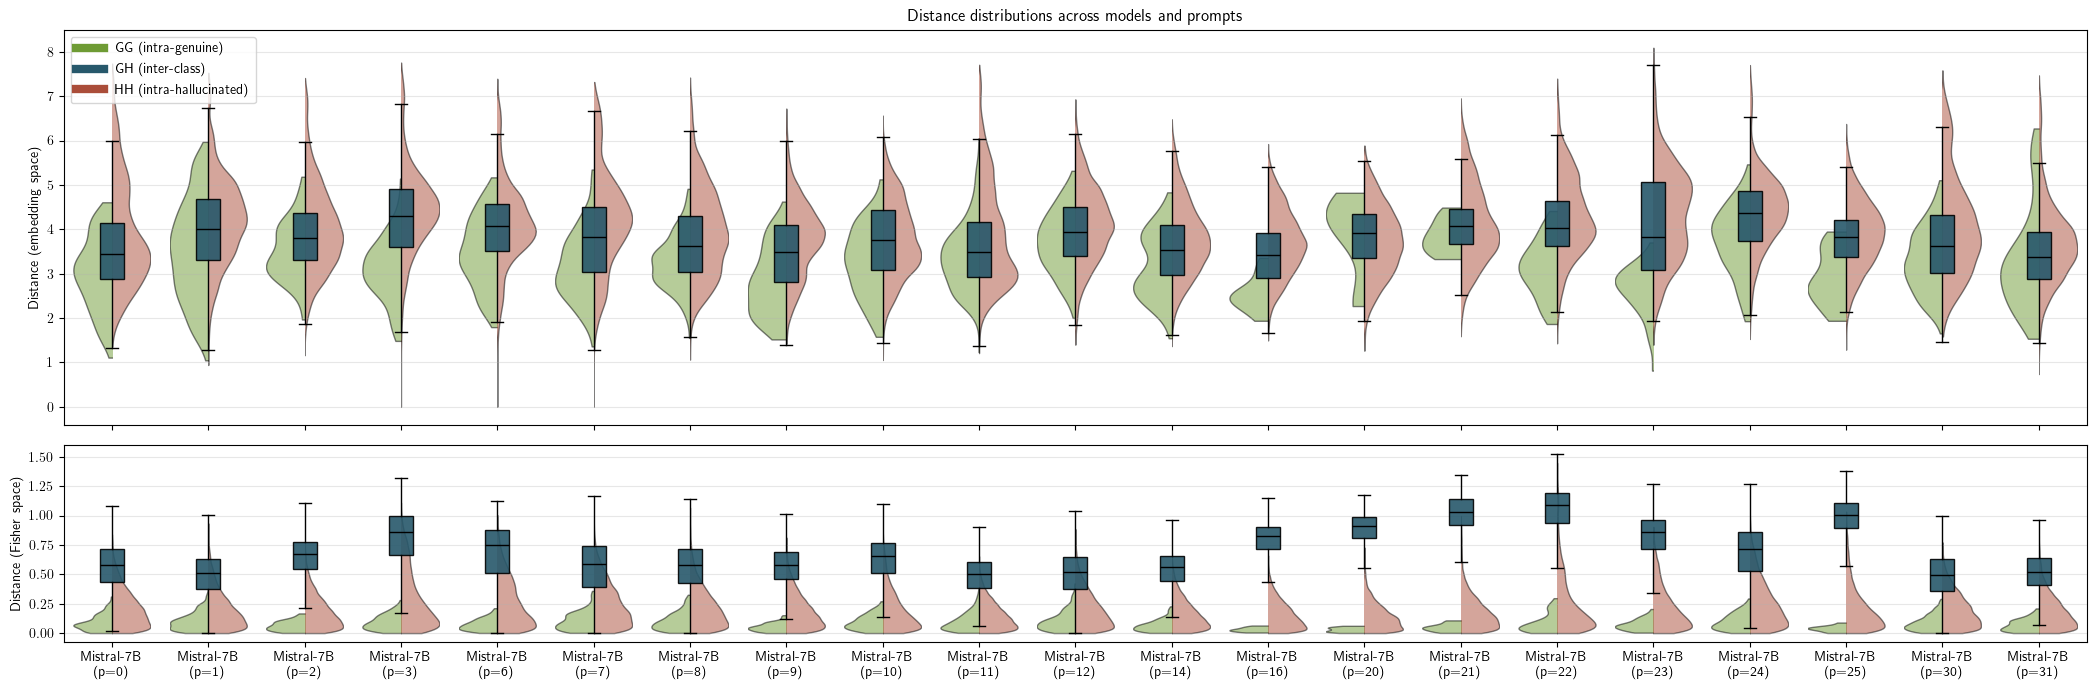

In [15]:
tmp_model_id = 0

selkeys = [(r['model_id'], r['prompt_id']) for _, r in results_df[(results_df['model_id'] == tmp_model_id) & (results_df['valid_plot'])].iterrows() ]

fig, axes = plot_violin_box_distance_panels_fisher(
    geometry_store=geometry_store,
    selected_keys=selkeys[:21],
    model_names=model_names,
    figsize=(21, 7)
)

### Ditributions per model and balancedeness -- Fig. 2

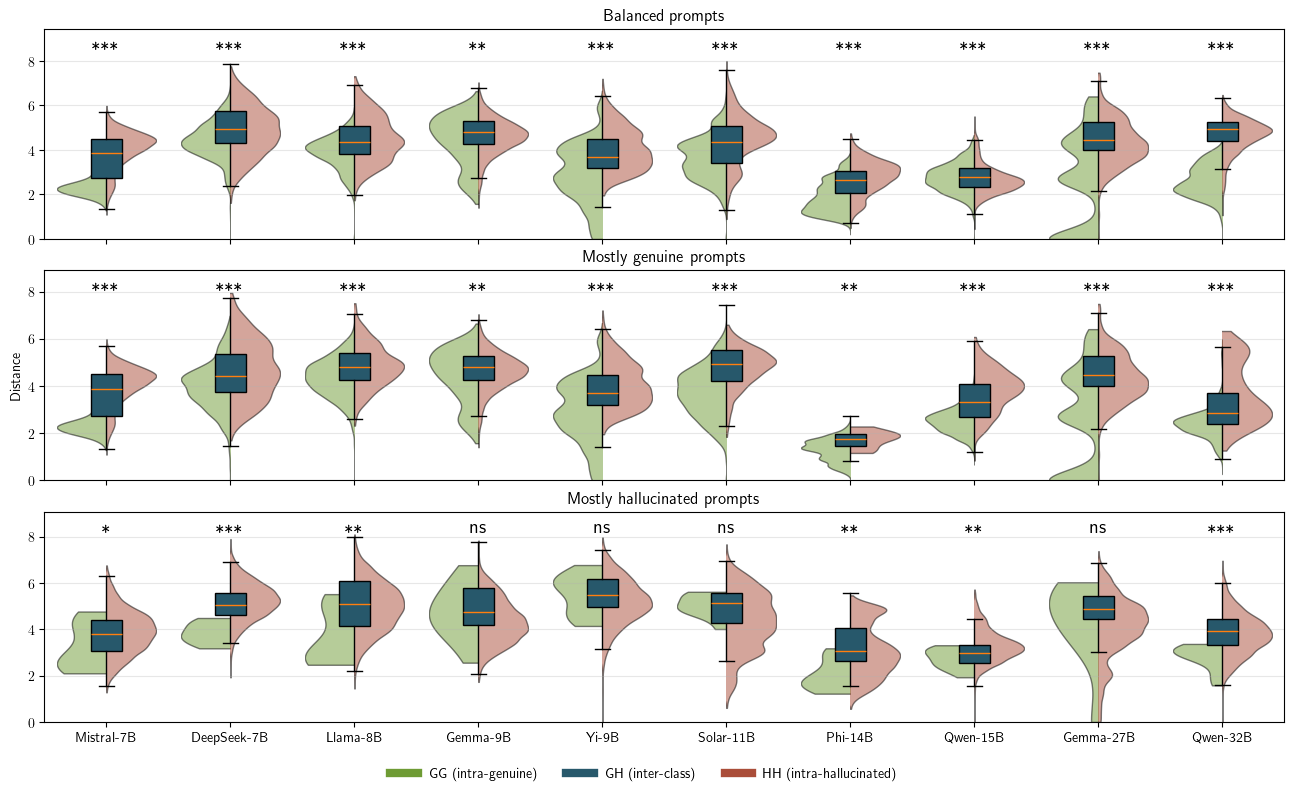

In [16]:
def plot_violin_box_distance_panels(
    geometry_store,
    selected_keys_dict,
    model_names,
    figsize=(16, 10),
    violin_width=0.8,
    box_width=0.25,
    alpha_violin=0.5,
    title=None
):
    """
    Three-panel plot (Balanced / Most genuine / Most hallucinated)
    using embedding-space distances only.
    """

    def gg_hh_pvalue(d_GG, d_HH):
        from scipy.stats import mannwhitneyu

        d_GG = np.asarray(d_GG)
        d_HH = np.asarray(d_HH)

        d_GG = d_GG[np.isfinite(d_GG)]
        d_HH = d_HH[np.isfinite(d_HH)]

        if len(d_GG) < 2 or len(d_HH) < 2:
            return np.nan

        _, p = mannwhitneyu(d_GG, d_HH, alternative="two-sided")
        return p

    def pvalue_to_stars(p):
        if not np.isfinite(p):
            return ""
        if p < 1e-3:
            return "***"
        elif p < 1e-2:
            return "**"
        elif p < 5e-2:
            return "*"
        else:
            return "ns"

    COLORS = {
        "GG": "#6E9B34",  # green
        "HH": "#AA4D39",  # red
        "GH": "#27586B",  # blue
    }

    panels = ["balanced", "most_genuine", "most_hallucinated"]
    panel_titles = {
        "balanced": "Balanced prompts",
        "most_genuine": "Mostly genuine prompts",
        "most_hallucinated": "Mostly hallucinated prompts",
    }

    fig, axes = plt.subplots(
        3, 1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={"hspace": 0.15}
    )

    def _plot_panel(ax, selected_keys, ylabel=None):
        n = len(selected_keys)
        x = np.arange(n)

        # ---- global y-limits (FORCED FROM 0)
        all_vals = []
        for k in selected_keys:
            d = geometry_store[k]
            all_vals.extend(d["D_GG"])
            all_vals.extend(d["D_HH"])
            all_vals.extend(d["D_GH"])

        all_vals = np.asarray(all_vals)
        all_vals = all_vals[np.isfinite(all_vals)]

        ymax = all_vals.max()
        ax.set_ylim(0, ymax * 1.12)

        y0, y1 = ax.get_ylim()
        height = y1 - y0

        for i, (m, p) in enumerate(selected_keys):
            d = geometry_store[(m, p)]

            # ---- GG: left half violin
            vp = ax.violinplot(
                d["D_GG"],
                positions=[x[i]],
                widths=violin_width,
                showextrema=False
            )
            for pc in vp["bodies"]:
                pc.set_facecolor(COLORS["GG"])
                pc.set_edgecolor("black")
                pc.set_alpha(alpha_violin)
                pc.set_clip_path(
                    Rectangle(
                        (x[i] - violin_width / 2, y0),
                        violin_width / 2,
                        height,
                        transform=ax.transData
                    )
                )

            # ---- HH: right half violin
            vp = ax.violinplot(
                d["D_HH"],
                positions=[x[i]],
                widths=violin_width,
                showextrema=False
            )
            for pc in vp["bodies"]:
                pc.set_facecolor(COLORS["HH"])
                pc.set_edgecolor("black")
                pc.set_alpha(alpha_violin)
                pc.set_clip_path(
                    Rectangle(
                        (x[i], y0),
                        violin_width / 2,
                        height,
                        transform=ax.transData
                    )
                )

            # ---- GH: boxplot
            bp = ax.boxplot(
                d["D_GH"],
                positions=[x[i]],
                widths=box_width,
                patch_artist=True,
                showfliers=False
            )
            for box in bp["boxes"]:
                box.set_facecolor(COLORS["GH"])
                box.set_edgecolor("black")

            # ---- significance stars (GG vs HH)
            pval = gg_hh_pvalue(d["D_GG"], d["D_HH"])
            stars = pvalue_to_stars(pval)
            if stars:
                ax.text(
                    x[i],
                    y1 - 0.03 * height,
                    stars,
                    ha="center",
                    va="top",
                    fontsize=14,
                    fontweight="bold"
                )

        if ylabel is not None:
            ax.set_ylabel(ylabel)

        ax.grid(True, axis="y", alpha=0.3)

    # ---- plot panels
    for ax, key in zip(axes, panels):
        _plot_panel(
            ax,
            selected_keys_dict[key],
            ylabel="Distance" if ax is axes[1] else None
        )
        ax.set_title(panel_titles[key])

    # ---- x labels: MODEL NAMES ONLY
    all_keys = selected_keys_dict[panels[0]]
    labels = [model_names[m] for m, _ in all_keys]

    axes[-1].set_xticks(np.arange(len(all_keys)))
    axes[-1].set_xticklabels(labels)

    # ---- legend: bottom, single row, outside
    handles = [
        plt.Line2D([0], [0], color=COLORS["GG"], lw=6, label="GG (intra-genuine)"),
        plt.Line2D([0], [0], color=COLORS["GH"], lw=6, label="GH (inter-class)"),
        plt.Line2D([0], [0], color=COLORS["HH"], lw=6, label="HH (intra-hallucinated)"),
    ]

    fig.legend(
        handles=handles,
        loc="lower center",
        ncol=3,
        frameon=False,
        bbox_to_anchor=(0.5, +0.03)
    )

    if title is not None:
        fig.suptitle(title, y=0.98, fontsize=14)

    # fig.tight_layout(rect=[0, 0.05, 1, 0.95])
    return fig, axes

# ===== ===== ===== ===== ===== ===== ===== =====

selected = {
    "balanced": [],
    "most_genuine": [],
    "most_hallucinated": [],
}

for mid in model_names:
    ans = ap.select_representative_prompts(results_df, model_id=mid)
    for kk, dd in ans.items():
        selected[kk].append((dd['model_id'], dd['prompt_id']))

selected_ordered = ap.reorder_selected_keys_by_model_size(selected, model_rank)

fig, axes = plot_violin_box_distance_panels(
    geometry_store=geometry_store,
    selected_keys_dict=selected_ordered,
    model_names=model_names,
    figsize=(16, 9),
    title=""
)

fig.savefig(f"{figures_dir}/S_promptViolins.pdf", bbox_inches='tight')

## Separability in Original and Fisher spaces -- Table 1

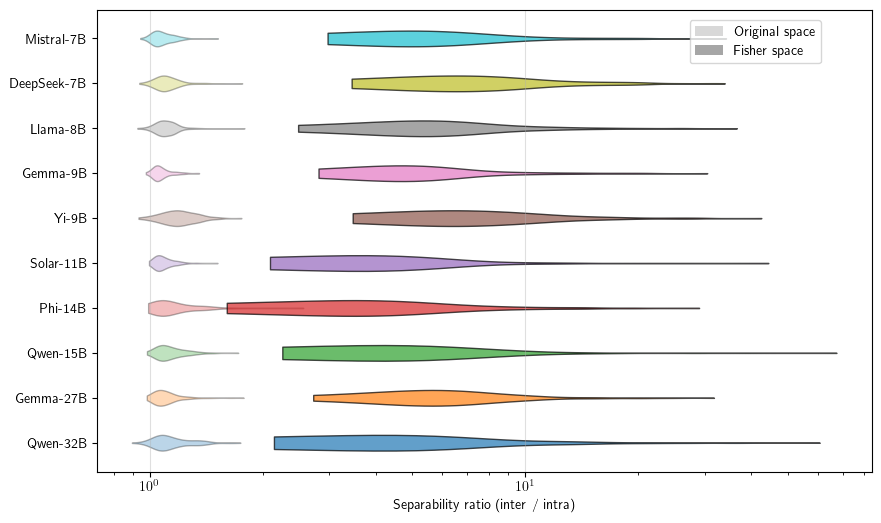

In [17]:
def plot_separability_violins_per_model(
    df_sep_long,
    model_names,
    model_order,
    ratio=(5, 3),
    scale=2,
    cmap_name="tab10",
    log_scale=True,
):
    fig, ax = plt.subplots(figsize=[scale * x for x in ratio])

    model_order = [x for x in reversed(model_order)]

    cmap = plt.get_cmap(cmap_name)

    y_positions = np.arange(len(model_order))
    width = 0.35

    for i, mid in enumerate(model_order):
        name = model_names[mid]
        color = cmap(i % cmap.N)

        for space, offset, alpha in [
            ("original", 0, 0.30),
            ("fisher",   0, 0.7),
        ]:
            vals = df_sep_long[
                (df_sep_long["model_id"] == mid) &
                (df_sep_long["space"] == space)
            ]["separability"].values

            if len(vals) == 0:
                continue

            vp = ax.violinplot(
                vals,
                positions=[y_positions[i] + offset],
                vert=False,
                widths=width,
                showmeans=False,
                showextrema=False,
                showmedians=False,
            )

            for body in vp["bodies"]:
                body.set_facecolor(color)
                body.set_edgecolor("black")
                body.set_alpha(alpha)

    ax.set_yticks(y_positions)
    ax.set_yticklabels([model_names[m] for m in model_order])

    if log_scale:
        ax.set_xscale("log")

    ax.set_xlabel("Separability ratio  (inter / intra)")
    # ax.set_title("Class separability across prompts\n(original vs Fisher space)")

    # legend proxy
    from matplotlib.patches import Patch
    legend_elems = [
        Patch(facecolor="gray", alpha=0.30, label="Original space"),
        Patch(facecolor="gray", alpha=0.7, label="Fisher space"),
    ]
    ax.legend(handles=legend_elems, bbox_to_anchor=(0.85, 0.93), loc='center')

    ax.grid(True, axis="x", alpha=0.4)

    return fig, ax

# ===== ===== ===== ===== ===== ===== ===== =====

df_ans = ap.build_separability_df(results_df, geometry_store)
df_sep_long = ap.prepare_separability_violin_df(df_ans)

fig, ax = plot_separability_violins_per_model(
    df_sep_long,
    model_names=model_names,
    model_order=model_order,
)

fig.savefig(f"{figures_dir}/S_FisherSeparability.pdf", bbox_inches='tight')

In [18]:
agg = (
    df_sep_long
    .groupby(["model_id", "space"])
    .agg(
        sep_mean=("separability", "mean"),
        sep_std=("separability", "std"),
    )
    .reset_index()
)

pivot = agg.pivot(
    index="model_id",
    columns="space",
    values=["sep_mean", "sep_std"]
)

# ordering_score = pivot["sep_mean", "fisher"]
# ordered_models = ordering_score.sort_values(ascending=False).index
pivot = pivot.loc[model_order]


def decorate_column(values):
    """
    values: list of floats
    returns: list of decorators ("bold", "underline", None)
    """
    order = np.argsort(values)[::-1]
    deco = [None] * len(values)
    if len(values) > 0:
        deco[order[0]] = "bold"
    if len(values) > 1:
        deco[order[1]] = "underline"
    return deco

orig_means = pivot["sep_mean", "original"].values
fish_means = pivot["sep_mean", "fisher"].values

orig_deco = decorate_column(orig_means)
fish_deco = decorate_column(fish_means)


table_df = pd.DataFrame({
    "Model": pivot.index.map(model_latextags),

    "Original space": [
        ap.apply_deco(ap.fmt(m, s), d)
        for m, s, d in zip(
            pivot["sep_mean", "original"],
            pivot["sep_std", "original"],
            orig_deco,
        )
    ],

    "Fisher space": [
        ap.apply_deco(ap.fmt(m, s), d)
        for m, s, d in zip(
            pivot["sep_mean", "fisher"],
            pivot["sep_std", "fisher"],
            fish_deco,
        )
    ],
})

avg_orig_mean = pivot["sep_mean", "original"].mean()
avg_orig_std  = pivot["sep_std", "original"].mean()

avg_fish_mean = pivot["sep_mean", "fisher"].mean()
avg_fish_std  = pivot["sep_std", "fisher"].mean()

avg_row = pd.DataFrame([{
    "Model": r"\textbf{Average}",
    "Original space": ap.fmt(avg_orig_mean, avg_orig_std),
    "Fisher space": ap.fmt(avg_fish_mean, avg_fish_std),
}])

table_df = pd.concat([table_df, avg_row], ignore_index=True)

latex_table = table_df.to_latex(
    index=False,
    escape=False,
    column_format="lcc",
)

print(latex_table)

\begin{tabular}{lcc}
\toprule
Model & Original space & Fisher space \\
\midrule
\MISTRAL & 1.09 (0.08) & 7.45 (5.68) \\
\DEEPSEEK & 1.12 (0.10) & \underline{9.44 (5.71)} \\
\LLAMA & 1.11 (0.09) & 7.71 (5.23) \\
\GEMMANINE & 1.08 (0.07) & 6.51 (4.25) \\
\YI & \textbf{1.21 (0.13)} & \textbf{9.53 (6.21)} \\
\SOLAR & 1.09 (0.07) & 5.29 (5.73) \\
\PHI & \underline{1.19 (0.21)} & 5.82 (4.96) \\
\QWENFOURTEEN & 1.15 (0.11) & 6.16 (6.50) \\
\GEMMATWENTYSEVEN & 1.11 (0.11) & 7.46 (4.24) \\
\QWENTHIRTYTWO & 1.17 (0.15) & 7.25 (7.46) \\
\textbf{Average} & 1.13 (0.11) & 7.26 (5.60) \\
\bottomrule
\end{tabular}



## Observed Wassersterin distances vs null distributions -- Table 10

In [19]:
# Collect per-model statistics

rows = []

for model_id in model_order:

    df_model = results_df[
        (results_df["model_id"] == model_id) &
        (results_df["valid_geom"])
    ]

    W_true = []
    W0_means = []

    for _, r in df_model.iterrows():
        key = (model_id, r["prompt_id"])
        if key not in null_store or len(null_store[key]) == 0:
            continue

        Wt = r["W_GG_HH"]
        W0 = np.asarray(null_store[key])

        W_true.append(Wt)
        W0_means.append(W0.mean())

    W_true = np.asarray(W_true)
    W0_means = np.asarray(W0_means)

    frac_above = (W_true > W0_means).mean() * 100

    rows.append({
        "model_id": model_id,
        "frac_above": frac_above,
        "true_mean": W_true.mean(),
        "true_std": W_true.std(),
        "null_mean": W0_means.mean(),
        "null_std": W0_means.std(),
    })

stats_df = pd.DataFrame(rows)

# Add global average row

avg_row = {
    "model_id": "avg",
    "frac_above": stats_df["frac_above"].mean(),
    "true_mean": stats_df["true_mean"].mean(),
    "true_std": stats_df["true_std"].mean(),
    "null_mean": stats_df["null_mean"].mean(),
    "null_std": stats_df["null_std"].mean(),
}

stats_df = pd.concat(
    [stats_df, pd.DataFrame([avg_row])],
    ignore_index=True
)

# Formatting helpers (bold / underline)

def decorate(values):
    order = np.argsort(values)[::-1]
    deco = [None] * len(values)
    if len(values) > 0:
        deco[order[0]] = "bold"
    if len(values) > 1:
        deco[order[1]] = "underline"
    return deco




# Column-wise decoration

mask_models = stats_df["model_id"] != "avg"
deco_frac = decorate(stats_df.loc[mask_models, "frac_above"].values)
deco_true = decorate(stats_df.loc[mask_models, "true_mean"].values)
deco_null = decorate(stats_df.loc[mask_models, "null_mean"].values)

# Build the table

table_rows = []

i_model = 0
for _, r in stats_df.iterrows():

    if r["model_id"] == "avg":
        table_rows.append({
            "Model": r"\textbf{Average}",
            r"$\%\,W > \bar W_{H_0}$": ap.fmt(r["frac_above"], prec=1) + r"\%",
            r"$\mathbb{E}[W]$": ap.fmt(r["true_mean"], r["true_std"]),
            r"$\mathbb{E}[\bar W_{H_0}]$": ap.fmt(r["null_mean"], r["null_std"]),
        })
        continue

    table_rows.append({
        "Model": model_latextags[r["model_id"]],
        r"$\%\,W > \bar W_{H_0}$": ap.apply_deco(
            ap.fmt(r["frac_above"], prec=1) + r"\%", deco_frac[i_model]
        ),
        r"$\mathbb{E}[W]$": ap.apply_deco(
            ap.fmt(r["true_mean"], r["true_std"]), deco_true[i_model]
        ),
        r"$\mathbb{E}[\bar W_{H_0}]$": ap.apply_deco(
            ap.fmt(r["null_mean"], r["null_std"]), deco_null[i_model]
        ),
    })

    i_model += 1

table_df = pd.DataFrame(table_rows)

# ... and export

latex_table = table_df.to_latex(
    index=False,
    escape=False,
    column_format="lccc",
)

print(latex_table)

\begin{tabular}{lccc}
\toprule
Model & $\%\,W > \bar W_{H_0}$ & $\mathbb{E}[W]$ & $\mathbb{E}[\bar W_{H_0}]$ \\
\midrule
\MISTRAL & 84.1\% & 0.93 (0.47) & 0.36 (0.21) \\
\DEEPSEEK & 88.0\% & \underline{1.07 (0.71)} & \underline{0.37 (0.23)} \\
\LLAMA & 86.2\% & 0.94 (0.52) & 0.32 (0.22) \\
\GEMMANINE & 81.5\% & 0.78 (0.49) & 0.32 (0.20) \\
\YI & \underline{92.7\%} & \textbf{1.81 (0.83)} & \textbf{0.44 (0.23)} \\
\SOLAR & 83.7\% & 0.93 (0.60) & 0.33 (0.21) \\
\PHI & 90.9\% & 0.91 (0.58) & 0.28 (0.22) \\
\QWENFOURTEEN & 91.6\% & 0.90 (0.48) & 0.31 (0.20) \\
\GEMMATWENTYSEVEN & 83.2\% & 0.83 (0.58) & 0.34 (0.20) \\
\QWENTHIRTYTWO & \textbf{94.5\%} & 1.06 (0.57) & 0.34 (0.25) \\
\textbf{Average} & 87.6\% & 1.02 (0.58) & 0.34 (0.22) \\
\bottomrule
\end{tabular}



## Fisher Direction Generalisation

The Fisher direction $\mathbf{v} \in \mathbb{R}^{384}$ is estimated independently for each
*(model, prompt)* pair.  The question is whether these directions are consistent —
i.e. whether the hallucination subspace is shared across prompts (within a model)
and across models (for the same prompt).

We measure consistency via **pairwise absolute cosine similarity**
$|\mathbf{v}_i \cdot \mathbf{v}_j|$ (absolute value because the sign of the Fisher
direction is arbitrary — it can be flipped without changing the classifier).

Two reference levels are plotted:
- **Within-model, cross-prompt** — same model, different prompts.
- **Cross-model, same prompt** — different models, same prompt.
- **Cross-model, cross-prompt** — different models *and* different prompts (background baseline).

A high within-model similarity would indicate that a single direction captures the
hallucination axis for a given model regardless of topic.  A high cross-model
similarity would indicate that the direction transfers across architectures.

In [20]:
# ── extract ──
vecs = ap.extract_fisher_directions(geometry_store, results_df)
print(f"Valid Fisher directions: {len(vecs)} pairs")

pairs = ap.collect_similarity_pairs(vecs)

for label, sims in pairs.items():
    print(f"  {label:20s}: n={len(sims):6d}   mean={sims.mean():.4f}   std={sims.std():.4f}   median={np.median(sims):.4f}")

Valid Fisher directions: 1777 pairs
  within_model        : n=157592   mean=0.0580   std=0.0448   median=0.0485
  cross_model_sp      : n=  7372   mean=0.1454   std=0.0885   median=0.1396
  cross_all           : n=1413012   mean=0.0547   std=0.0416   median=0.0461


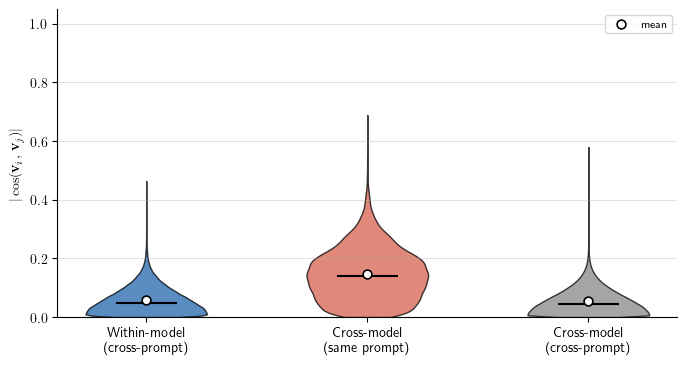

In [21]:
# ── Violin: distribution of |cos sim| across the three pairing types ──────────

GROUP_LABELS = {
    "within_model":   "Within-model\n(cross-prompt)",
    "cross_model_sp": "Cross-model\n(same prompt)",
    "cross_all":      "Cross-model\n(cross-prompt)",
}

GROUP_COLORS = {
    "within_model":   "#2166ac",
    "cross_model_sp": "#d6604d",
    "cross_all":      "#878787",
}

fig, ax = plt.subplots(figsize=(8, 4))

positions  = [1, 2, 3]
data_order = ["within_model", "cross_model_sp", "cross_all"]

vp = ax.violinplot(
    [pairs[k] for k in data_order],
    positions  = positions,
    vert       = True,
    widths     = 0.55,
    showmeans  = False,
    showextrema= False,
    showmedians= True,
)

for body, key in zip(vp["bodies"], data_order):
    body.set_facecolor(GROUP_COLORS[key])
    body.set_edgecolor("black")
    body.set_alpha(0.75)

vp["cmedians"].set_color("black")
vp["cmedians"].set_linewidth(1.5)

# overlay means
for pos, key in zip(positions, data_order):
    ax.scatter(pos, pairs[key].mean(), color="white", edgecolors="black",
               zorder=5, s=40, linewidths=1.2, label="mean" if pos == 1 else "_")

ax.set_xticks(positions)
ax.set_xticklabels([GROUP_LABELS[k] for k in data_order], fontsize=10)
ax.set_ylabel(r"$|\cos(\mathbf{v}_i,\, \mathbf{v}_j)|$")
ax.set_ylim(0, 1.05)
ax.grid(axis="y", alpha=0.35)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=8, loc="upper right")

# plt.tight_layout()
# fig.savefig(f"{figures_dir}/S_FisherDirectionGeneralisation_violin.pdf", bbox_inches="tight")
# plt.show()

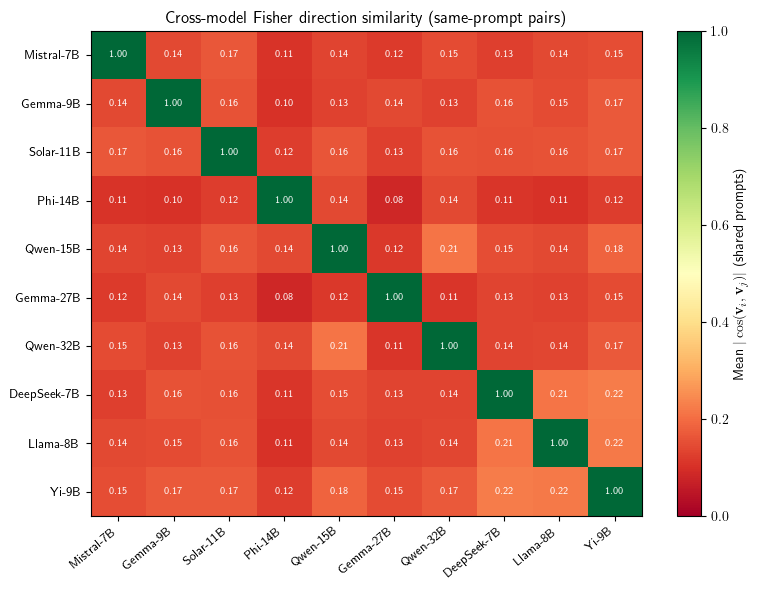

In [22]:
# ── Per-model mean cosine similarity to all other models (same prompt) ────────
# For each model, and for each prompt that model shares with at least one other
# model, we collect the absolute cosine similarities to the other models' Fisher
# directions at that prompt and average.

model_ids_present = sorted(set(m for m, p in vecs))

# Build a (model × model) matrix of mean |cos sim|, restricted to shared prompts.
n_models = len(model_ids_present)
sim_matrix = np.full((n_models, n_models), np.nan)

for i, mi in enumerate(model_ids_present):
    for j, mj in enumerate(model_ids_present):
        if mi == mj:
            sim_matrix[i, j] = 1.0
            continue
        # prompts available for both models
        prompts_i = {p for m, p in vecs if m == mi}
        prompts_j = {p for m, p in vecs if m == mj}
        shared     = prompts_i & prompts_j
        if not shared:
            continue
        sims = [
            float(np.abs(np.dot(vecs[(mi, p)], vecs[(mj, p)])))
            for p in shared
        ]
        sim_matrix[i, j] = np.mean(sims)

# ── plot ──

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(sim_matrix, vmin=0, vmax=1, cmap="RdYlGn", aspect="auto")

model_labels = [model_names[m] for m in model_ids_present]
ax.set_xticks(range(n_models))
ax.set_yticks(range(n_models))
ax.set_xticklabels(model_labels, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(model_labels, fontsize=9)

for (i, j), val in np.ndenumerate(sim_matrix):
    if not np.isnan(val):
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=7,
                color="black" if 0.3 < val < 0.85 else "white")

plt.colorbar(im, ax=ax, label=r"Mean $|\cos(\mathbf{v}_i, \mathbf{v}_j)|$ (shared prompts)")
ax.set_title("Cross-model Fisher direction similarity (same-prompt pairs)")

plt.tight_layout()
fig.savefig(f"{figures_dir}/S_FisherDirectionGeneralisation_heatmap.pdf", bbox_inches="tight")
plt.show()

In [23]:
# ── Summary statistics table (LaTeX) ─────────────────────────────────────────

def fmt_sim(arr):
    """Mean ± std formatted as 'X.XXX (X.XXX)'."""
    return f"{arr.mean():.3f} ({arr.std():.3f})"

rows = []

# --- global summary ---
rows.append({
    "Comparison":  r"Within-model (cross-prompt)",
    "$n$ pairs":   f"{len(pairs['within_model']):,}",
    r"Mean $|\cos|$": fmt_sim(pairs["within_model"]),
    r"Median $|\cos|$": f"{np.median(pairs['within_model']):.3f}",
})
rows.append({
    "Comparison":  r"Cross-model (same prompt)",
    "$n$ pairs":   f"{len(pairs['cross_model_sp']):,}",
    r"Mean $|\cos|$": fmt_sim(pairs["cross_model_sp"]),
    r"Median $|\cos|$": f"{np.median(pairs['cross_model_sp']):.3f}",
})
rows.append({
    "Comparison":  r"Cross-model (cross-prompt)",
    "$n$ pairs":   f"{len(pairs['cross_all']):,}",
    r"Mean $|\cos|$": fmt_sim(pairs["cross_all"]),
    r"Median $|\cos|$": f"{np.median(pairs['cross_all']):.3f}",
})

table_df = pd.DataFrame(rows)

latex_table = table_df.to_latex(
    index         = False,
    escape        = False,
    column_format = "lccc",
    caption       = (
        r"Fisher direction generalisation. "
        r"Absolute cosine similarity $|\cos(\mathbf{v}_i, \mathbf{v}_j)|$ "
        r"between independently estimated Fisher directions, partitioned by "
        r"pairing type. Values close to 1 indicate that the hallucination "
        r"subspace is consistent across the paired condition."
    ),
    label = "tab:fisher_generalisation",
)

print(latex_table)

\begin{table}
\caption{Fisher direction generalisation. Absolute cosine similarity $|\cos(\mathbf{v}_i, \mathbf{v}_j)|$ between independently estimated Fisher directions, partitioned by pairing type. Values close to 1 indicate that the hallucination subspace is consistent across the paired condition.}
\label{tab:fisher_generalisation}
\begin{tabular}{lccc}
\toprule
Comparison & $n$ pairs & Mean $|\cos|$ & Median $|\cos|$ \\
\midrule
Within-model (cross-prompt) & 157,592 & 0.058 (0.045) & 0.048 \\
Cross-model (same prompt) & 7,372 & 0.145 (0.089) & 0.140 \\
Cross-model (cross-prompt) & 1,413,012 & 0.055 (0.042) & 0.046 \\
\bottomrule
\end{tabular}
\end{table}

